## Model comparison across model 1, 2, 3

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, f1_score,
    precision_recall_curve, average_precision_score,
    roc_auc_score
)
import os

os.makedirs('figures', exist_ok=True)




In [3]:
# from google.colab import drive
# drive.mount('/content/drive')
# DataPath = "drive/MyDrive/JHU/MLMA/final project" # Change to your path
# %cd $DataPath

In [4]:
# model config
MODELS = {
    'model1': '1D CNN (Temporal)',
    'model2': '2D CNN (Spectral)',
    'model3': 'Multi-modal Fusion'
}

COLORS = {
    'model1': 'blue',
    'model2': 'green',
    'model3': 'red' 
}


In [5]:
# load results

results = {}

for model_key in MODELS.keys():
    if model_key == 'model3':  # Skip heartbeat loading for model3 as it doesn't exist
        results[model_key] = {
            'patient_probs': np.load(f'results/{model_key}_patient_probs.npy'),
            'patient_labels': np.load(f'results/{model_key}_patient_labels.npy'),
            'patient_ids': np.load(f'results/{model_key}_patient_ids.npy', allow_pickle=True),
            'threshold': np.load(f'results/{model_key}_threshold.npy')[0]
        }
        print(f"Loaded {model_key}: {len(results[model_key]['patient_probs'])} patients")
    else: 
        results[model_key] = {
            'patient_probs': np.load(f'results/{model_key}_patient_probs.npy'),
            'patient_labels': np.load(f'results/{model_key}_patient_labels.npy'),
            'patient_ids': np.load(f'results/{model_key}_patient_ids.npy', allow_pickle=True),
            'threshold': np.load(f'results/{model_key}_threshold.npy')[0],
            'hb_probs': np.load(f'results/{model_key}_hb_probs.npy'),
            'hb_labels': np.load(f'results/{model_key}_hb_labels.npy'),
            'hb_patient_ids': np.load(f'results/{model_key}_hb_patient_ids.npy', allow_pickle=True),
            'hb_locations': np.load(f'results/{model_key}_hb_locations.npy', allow_pickle=True)
        }
        print(f"Loaded {model_key}: {len(results[model_key]['patient_probs'])} patients, {len(results[model_key]['hb_probs'])} heartbeats")

Loaded model1: 175 patients, 12275 heartbeats
Loaded model2: 175 patients, 12275 heartbeats
Loaded model3: 175 patients


In [6]:
# compute metrics
def compute_all_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        'AUC': roc_auc_score(y_true, y_prob),
        'AUPRC': average_precision_score(y_true, y_prob),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'Threshold': threshold,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
    }

def aggregate_to_patient_level(preds, labels, patient_ids):
    df = pd.DataFrame({'patient_id': patient_ids, 'pred': preds, 'label': labels})
    return df.groupby('patient_id').agg({'pred': 'max', 'label': 'max'}).reset_index()

metrics = {}
for model_key in MODELS.keys():
    r = results[model_key]
    metrics[model_key] = compute_all_metrics(
        r['patient_labels'], r['patient_probs'], r['threshold']
    )

In [7]:
# summary table - sanity check
summary_data = []
for model_key, label in MODELS.items():
    m = metrics[model_key]
    summary_data.append({
        'Model': label,
        'AUC': f"{m['AUC']:.3f}",
        'AUPRC': f"{m['AUPRC']:.3f}",
        'F1': f"{m['F1']:.3f}",
        'Sensitivity': f"{m['Sensitivity']:.3f}",
        'Specificity': f"{m['Specificity']:.3f}",
        'Threshold': f"{m['Threshold']:.3f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY (Patient-Level)")
print("="*70)
print(summary_df.to_string(index=False))
summary_df.to_csv('results/model_comparison_summary.csv', index=False)



MODEL COMPARISON SUMMARY (Patient-Level)
             Model   AUC AUPRC    F1 Sensitivity Specificity Threshold
 1D CNN (Temporal) 0.719 0.507 0.357       0.917       0.165     0.907
 2D CNN (Spectral) 0.707 0.498 0.484       0.639       0.741     0.843
Multi-modal Fusion 0.830 0.546 0.393       0.944       0.259     0.994


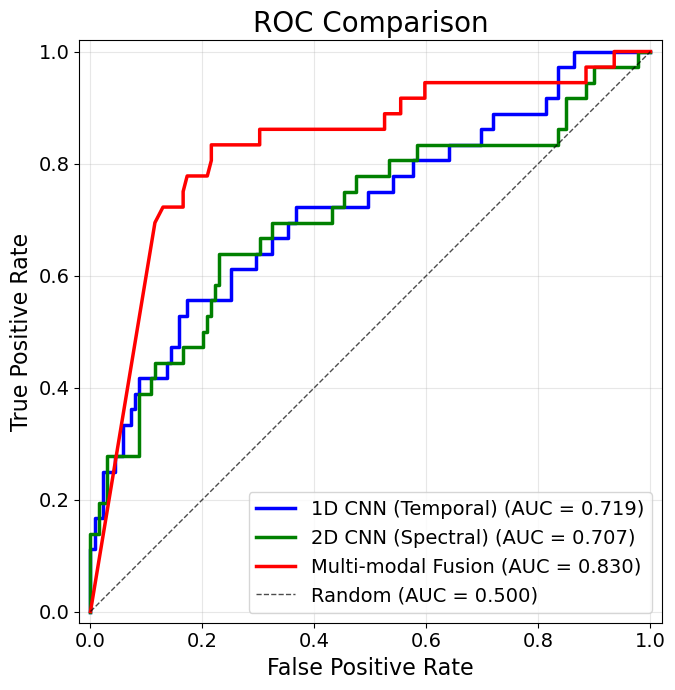

In [8]:
# fig1: roc curve
plt.rcdefaults()  # Reset matplotlib to default state

fig, ax = plt.subplots(figsize=(7, 7))

for model_key, label in MODELS.items():
    r = results[model_key]
    fpr, tpr, _ = roc_curve(r['patient_labels'], r['patient_probs'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2.5, color=COLORS[model_key],
            label=f"{label} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.7, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=16)
ax.set_ylabel('True Positive Rate', fontsize=16)
ax.set_title('ROC Comparison', fontsize=20)
ax.legend(loc='lower right', fontsize=14)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

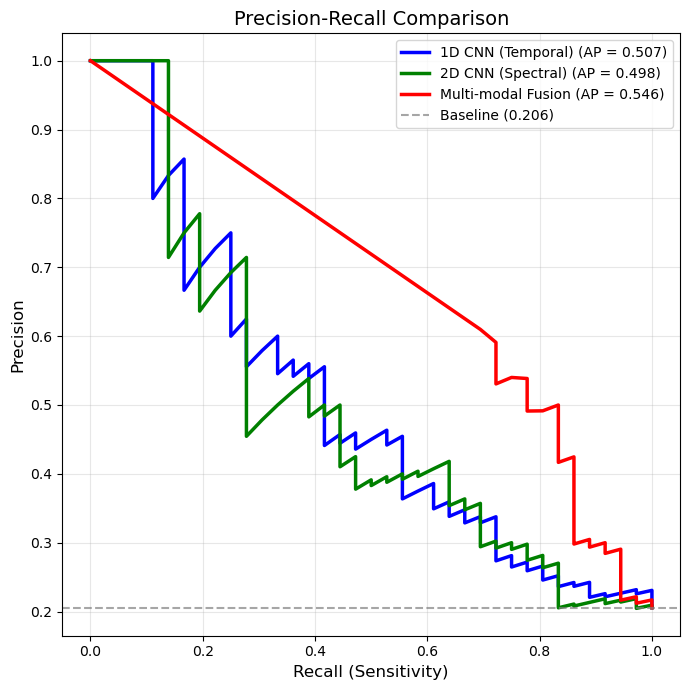

In [9]:
# fig2 - precision recall curves

fig, ax = plt.subplots(figsize=(7, 7))

for model_key, label in MODELS.items():
    r = results[model_key]
    precision, recall, _ = precision_recall_curve(r['patient_labels'], r['patient_probs'])
    ap = average_precision_score(r['patient_labels'], r['patient_probs'])
    ax.plot(recall, precision, lw=2.5, color=COLORS[model_key],
            label=f"{label} (AP = {ap:.3f})")

baseline = results['model1']['patient_labels'].mean()
ax.axhline(y=baseline, color='gray', linestyle='--', alpha=0.7, label=f'Baseline ({baseline:.3f})')

ax.set_xlabel('Recall (Sensitivity)', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Comparison', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pr_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

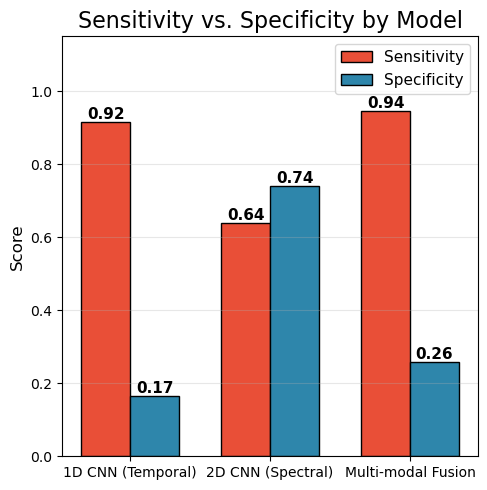

In [10]:
# sensitivity vs. specificity
fig, ax = plt.subplots(figsize=(5, 5))

x = np.arange(len(MODELS))
width = 0.35

sensitivity = [metrics[m]['Sensitivity'] for m in MODELS.keys()]
specificity = [metrics[m]['Specificity'] for m in MODELS.keys()]

bars1 = ax.bar(x - width/2, sensitivity, width, label='Sensitivity', color='#E94F37', edgecolor='black')
bars2 = ax.bar(x + width/2, specificity, width, label='Specificity', color='#2E86AB', edgecolor='black')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Sensitivity vs. Specificity by Model', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels([MODELS[m] for m in MODELS.keys()])
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('sensitivity_specificity.png', dpi=300, bbox_inches='tight')
plt.show()

findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.


findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not

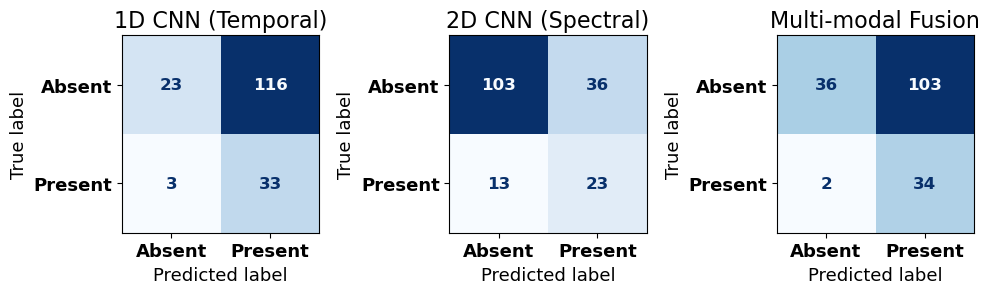

In [16]:

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
font = {'family' : 'normal', 'size'   : 12}
plt.rc('font', **font)

for ax, (model_key, label) in zip(axes, MODELS.items()):
    r = results[model_key]
    y_pred = (r['patient_probs'] >= r['threshold']).astype(int)
    cm = confusion_matrix(r['patient_labels'], y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Absent', 'Present'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{label}", fontsize=16)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()



ZONE-SPECIFIC ANALYSIS


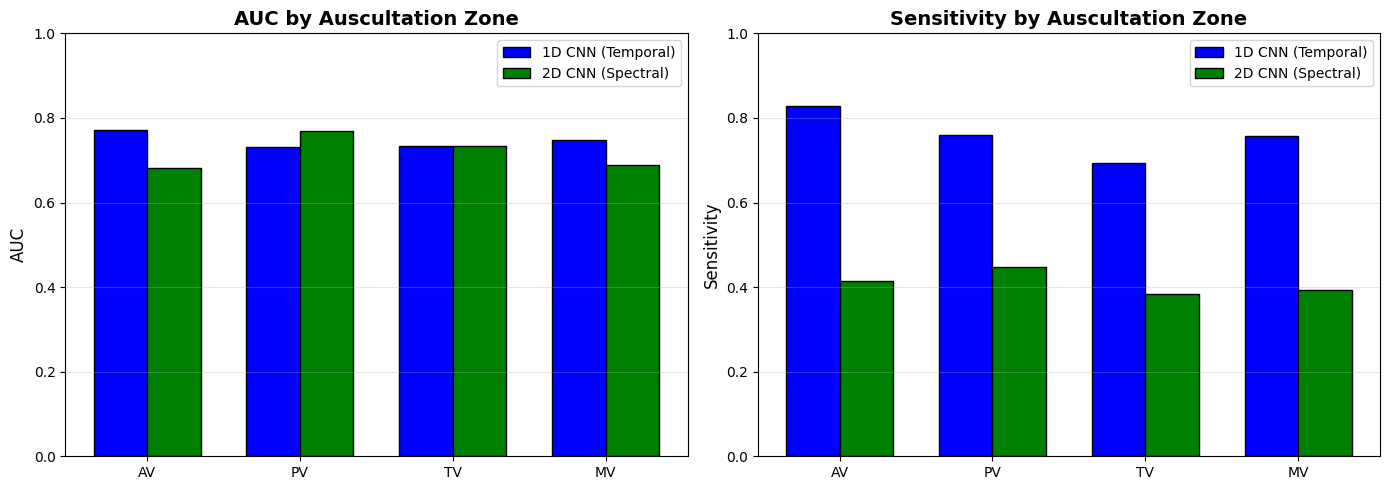

In [12]:
# zone specific analysis
zones = ['AV', 'PV', 'TV', 'MV']
zone_auc = {model_key: [] for model_key in MODELS.keys()}
zone_sens = {model_key: [] for model_key in MODELS.keys()}

print("\n" + "="*60)
print("ZONE-SPECIFIC ANALYSIS")
print("="*60)

for zone in zones:
    for model_key in MODELS.keys():
        r = results[model_key]
        loc_mask = r['hb_locations'] == zone

        if loc_mask.sum() == 0:
            zone_auc[model_key].append(0.5)
            zone_sens[model_key].append(0)
            continue

        loc_patient_df = aggregate_to_patient_level(
            r['hb_probs'][loc_mask],
            r['hb_labels'][loc_mask],
            r['hb_patient_ids'][loc_mask]
        )

        try:
            loc_auc = roc_auc_score(loc_patient_df['label'], loc_patient_df['pred'])
        except:
            loc_auc = 0.5
        zone_auc[model_key].append(loc_auc)

        y_pred = (loc_patient_df['pred'] >= r['threshold']).astype(int)
        y_true = loc_patient_df['label'].values
        if y_true.sum() > 0:
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        else:
            sens = 0
        zone_sens[model_key].append(sens)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(zones))
width = 0.35

for i, (model_key, label) in enumerate(MODELS.items()):
    axes[0].bar(x + i*width - width/2, zone_auc[model_key], width,
                label=label, color=COLORS[model_key], edgecolor='black')
    axes[1].bar(x + i*width - width/2, zone_sens[model_key], width,
                label=label, color=COLORS[model_key], edgecolor='black')

for ax, title, ylabel in [(axes[0], 'AUC by Auscultation Zone', 'AUC'),
                           (axes[1], 'Sensitivity by Auscultation Zone', 'Sensitivity')]:
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(zones)
    ax.legend(fontsize=10)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('zone_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [13]:
# zones table

zone_table = []
for i, zone in enumerate(zones):
    row = {'Zone': zone}
    for model_key, label in MODELS.items():
        row[f'{label} AUC'] = f"{zone_auc[model_key][i]:.3f}"
        row[f'{label} Sens'] = f"{zone_sens[model_key][i]:.3f}"
    zone_table.append(row)

zone_df = pd.DataFrame(zone_table)
print("\nZone-Specific Performance:")
print(zone_df.to_string(index=False))
zone_df.to_csv('zone_comparison.csv', index=False)



Zone-Specific Performance:
Zone 1D CNN (Temporal) AUC 1D CNN (Temporal) Sens 2D CNN (Spectral) AUC 2D CNN (Spectral) Sens
  AV                 0.771                  0.828                 0.682                  0.414
  PV                 0.730                  0.759                 0.769                  0.448
  TV                 0.734                  0.692                 0.733                  0.385
  MV                 0.748                  0.758                 0.688                  0.394
